# Dataset de Regressão — Wind Power Generation

- Os dados foram retirados do site [Kaggle](https://www.kaggle.com/datasets/mubashirrahim/wind-power-generation-data-forecasting/discussion/473581) e contêm informações sobre as condições meteorológicas e a produção de energia de turbinas eólicas submetidas a essas condições.
- Cada instância representa uma medição da capacidade de energia gerada, juntamente com as variáveis meteorológicas correspondentes ao dia e horário da medição.

#### Observações
- O dataset fornece uma base adequada para o treinamento de modelos de Machine Learning voltados à regressão, com o objetivo de prever a produção de energia.
- No entanto, sua aplicação em um cenário real pode ser limitada, considerando que o provedor dos dados não informou a localização geográfica onde as medições foram realizadas.


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
# carregamento inicial dos dados
df = pd.read_csv("../data/raw/wind-power-generation.csv", encoding='utf-8')

print(df.head())
print(df.shape)

                  Time  temperature_2m  relativehumidity_2m  dewpoint_2m  \
0  2017-01-02 00:00:00            28.5                   85         24.5   
1  2017-01-02 01:00:00            28.4                   86         24.7   
2  2017-01-02 02:00:00            26.8                   91         24.5   
3  2017-01-02 03:00:00            27.4                   88         24.3   
4  2017-01-02 04:00:00            27.3                   88         24.1   

   windspeed_10m  windspeed_100m  winddirection_10m  winddirection_100m  \
0           1.44            1.26                146                 162   
1           2.06            3.99                151                 158   
2           1.30            2.78                148                 150   
3           1.30            2.69                 58                 105   
4           2.47            4.43                 58                  84   

   windgusts_10m   Power  
0            1.4  0.1635  
1            4.4  0.1424  
2          

In [4]:
# visualização das informações principais do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43800 entries, 0 to 43799
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Time                 43800 non-null  object 
 1   temperature_2m       43800 non-null  float64
 2   relativehumidity_2m  43800 non-null  int64  
 3   dewpoint_2m          43800 non-null  float64
 4   windspeed_10m        43800 non-null  float64
 5   windspeed_100m       43800 non-null  float64
 6   winddirection_10m    43800 non-null  int64  
 7   winddirection_100m   43800 non-null  int64  
 8   windgusts_10m        43800 non-null  float64
 9   Power                43800 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 3.3+ MB


In [5]:
# estatísticas descritivas
df.describe(include='all')

,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
count,43800,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000
unique,43800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2017-01-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,47.862911,72.288744,38.569308,3.591147,6.284431,203.637329,203.343676,7.771795,0.405385
std,NaN,19.453691,16.852287,18.772110,1.649318,2.685216,96.371262,97.959852,3.569147,0.288322
min,NaN,-14.400000,18.000000,-17.100000,0.000000,0.100000,1.000000,0.000000,0.500000,0.000000
25%,NaN,32.100000,60.000000,24.300000,2.410000,4.380000,132.000000,130.000000,5.000000,0.148900
50%,NaN,47.300000,74.000000,38.100000,3.300000,6.080000,225.000000,226.000000,7.200000,0.347650
75%,NaN,64.500000,86.000000,54.700000,4.590000,7.990000,277.000000,278.000000,10.000000,0.659600


In [6]:
# validando a existencia valores ausentes
df.isnull().sum()

Time                   0
temperature_2m         0
relativehumidity_2m    0
dewpoint_2m            0
windspeed_10m          0
windspeed_100m         0
winddirection_10m      0
winddirection_100m     0
windgusts_10m          0
Power                  0
dtype: int64

### Transformação de Features

In [7]:
df['hour'] = pd.to_datetime(df['Time']).dt.hour

for col in ['winddirection_10m', 'winddirection_100m']:
    rad = np.deg2rad(df[col])
    df[col + '_sin'] = np.sin(rad)
    df[col + '_cos'] = np.cos(rad)

df = df.drop(columns=['Time','winddirection_10m','winddirection_100m'])

df.isna().sum()

temperature_2m            0
relativehumidity_2m       0
dewpoint_2m               0
windspeed_10m             0
windspeed_100m            0
windgusts_10m             0
Power                     0
hour                      0
winddirection_10m_sin     0
winddirection_10m_cos     0
winddirection_100m_sin    0
winddirection_100m_cos    0
dtype: int64

In [8]:
X = df.drop(columns=['Power'])
y = df['Power']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

### 1. Support Vector Regression (SVR)

In [9]:
pipe_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR())
])

param_svr = {
    'model__C': [1.0, 10.0],
    'model__epsilon': [0.1],
    'model__kernel': ['rbf']
}

grid_svr = GridSearchCV( pipe_svr, param_svr, cv=cv, scoring='r2', n_jobs=-1)
grid_svr.fit(X_train, y_train)

,estimator,"Pipeline(step...del', SVR())])"
,param_grid,"{'model__C': [1.0, 10.0], 'model__epsilon': [0.1], 'model__kernel': ['rbf']}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


### 2. Random Forest Regressor

In [10]:
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42))
])

param_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 8, 10, 15],
    'model__min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV( pipe_rf, param_rf, cv=cv, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [3, 5, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


### 3. Gradient Boosting Regressor

In [11]:
pipe_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(random_state=42))
])

param_gb = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [4, 5, 8, 10, 15]
}

grid_gb = GridSearchCV( pipe_gb, param_gb, cv=cv, scoring='r2', n_jobs=-1)
grid_gb.fit(X_train, y_train)


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [4, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


### Resultados

In [12]:
fit_results = pd.DataFrame({
    "Modelo": ["SVR", "Random Forest", "Gradient Boosting"],
    "R2":[
        grid_svr.best_score_,
        grid_rf.best_score_,
        grid_gb.best_score_
    ]
})

fit_results.sort_values(by="R2", ascending=False)

,Modelo,R2
2,Gradient Boosting,0.742900
1,Random Forest,0.732973
0,SVR,0.727410


In [13]:
best_models = {}

best_models["SVR"] = grid_svr
best_models["Gradient Boosting"] = grid_gb
best_models["Random Forest"] = grid_rf

### Resultados de Teste
- De cada Modelo após os treino foi escolhido a melhor combinação de hyperparamentros e feitos os testes. Utilizando as métricas R2 e RMSE para a análise e comparação dos modelos 

In [14]:
from math import sqrt

results = {}

for name, grid in best_models.items():
    best = grid.best_estimator_
    preds = best.predict(X_test)
    
    r2 = r2_score(y_test, preds)
    rmse = sqrt(mean_squared_error(y_test, preds))
    
    results[name] = {
        'R2': r2,
        'RMSE': rmse,
        'Melhores hiperparâmetros': grid.best_params_
    }

pd_results = pd.DataFrame(results)


df_results = pd_results.T.sort_values("R2", ascending=False)
print(df_results)

best_model_name = df_results.index[0]
print(f"\nMelhor modelo pelo R²: {best_model_name}")
print("Melhores hiperparâmetros:", results[best_model_name]["Melhores hiperparâmetros"])



                         R2      RMSE  \
Gradient Boosting  0.741964  0.146127   
Random Forest      0.729738  0.149549   
SVR                0.722546  0.151526   

                                            Melhores hiperparâmetros  
Gradient Boosting  {'model__learning_rate': 0.05, 'model__max_dep...  
Random Forest      {'model__max_depth': 15, 'model__min_samples_s...  
SVR                {'model__C': 10.0, 'model__epsilon': 0.1, 'mod...  

Melhor modelo pelo R²: Gradient Boosting
Melhores hiperparâmetros: {'model__learning_rate': 0.05, 'model__max_depth': 10, 'model__n_estimators': 400}


### Comparação gráfica de resultados por Métrica

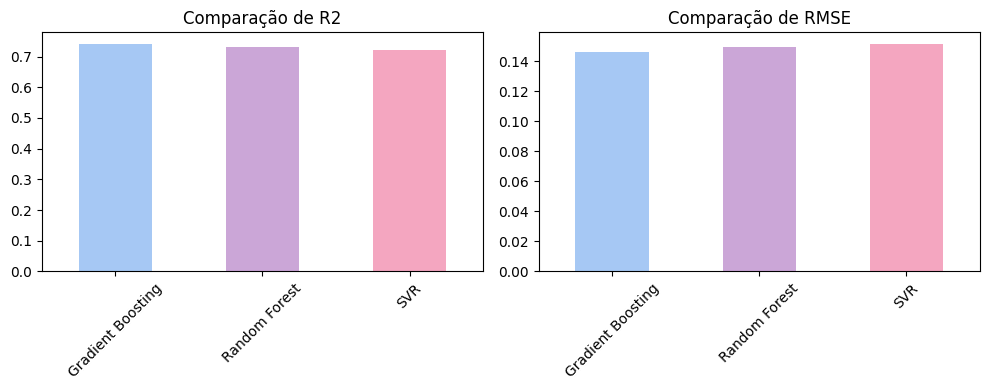

In [15]:
from matplotlib import pyplot as plt


plt.figure(figsize=(10,4))

# R² plot
plt.subplot(1,2,1)
df_results["R2"].plot(kind='bar', title='Comparação de R2', color= ['#A6C8F4','#CBA6D7', '#F4A6C0'])
plt.xticks(rotation=45)

# RMSE plot
plt.subplot(1,2,2)
df_results["RMSE"].plot(kind='bar', title='Comparação de RMSE', color= ['#A6C8F4','#CBA6D7', '#F4A6C0'])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### Análise da Importancia de cada feature para cada modelo


=== Importância de cada Feature: SVR ===


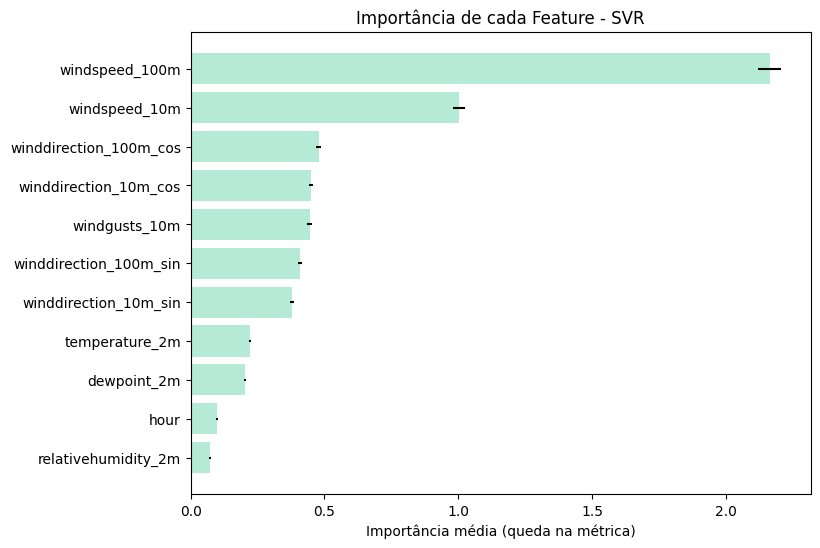


=== Importância de cada Feature: Gradient Boosting ===


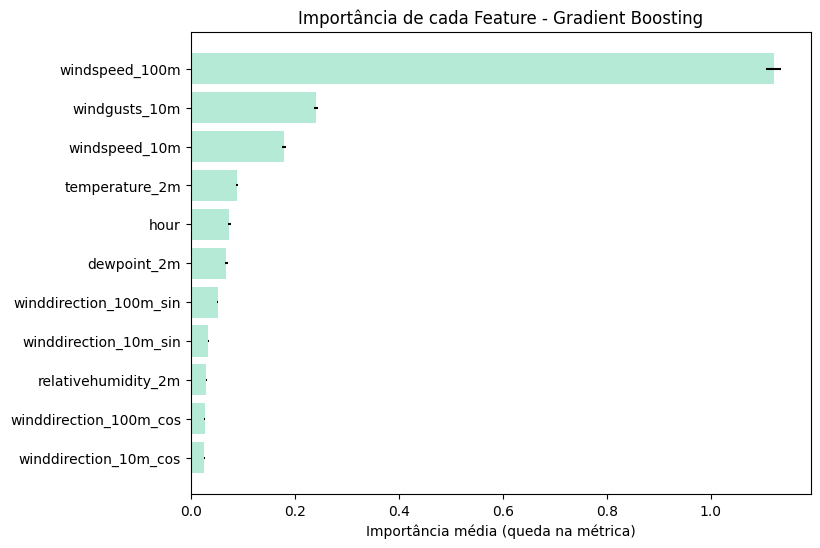


=== Importância de cada Feature: Random Forest ===


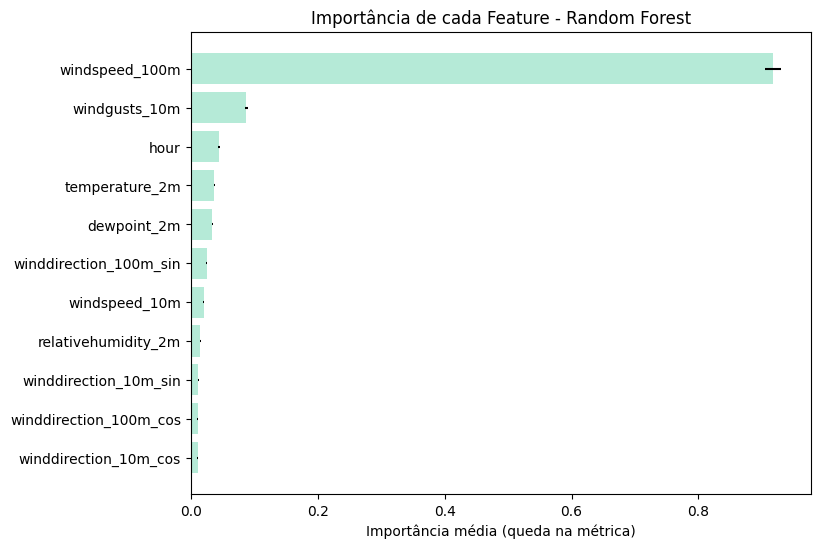

In [16]:
from sklearn.inspection import permutation_importance

for name, grid in best_models.items():
    model = grid.best_estimator_
    
    print(f"\n=== Importância de cada Feature: {name} ===")
    
    result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
    
    importance_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values(by="importance_mean", ascending=True)
    
    plt.figure(figsize=(8,6))
    plt.barh(importance_df["feature"], importance_df["importance_mean"], xerr=importance_df["importance_std"], color="#B5EAD7")
    plt.title(f"Importância de cada Feature - {name}")
    plt.xlabel("Importância média (queda na métrica)")
    plt.show()


In [17]:
print("\nMelhores Hiperparâmetros de Cada Modelo:\n")

for name, grid in best_models.items():
    print(f"{name}:")
    print(grid.best_params_)
    print("-" * 40)



Melhores Hiperparâmetros de Cada Modelo:

SVR:
{'model__C': 10.0, 'model__epsilon': 0.1, 'model__kernel': 'rbf'}
----------------------------------------
Gradient Boosting:
{'model__learning_rate': 0.05, 'model__max_depth': 10, 'model__n_estimators': 400}
----------------------------------------
Random Forest:
{'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 300}
----------------------------------------
